# Feature Engineering, Cross-Validation & Model Comparison
Builds on Day 1 (baselines) and Day 2 (preprocessing pipeline, Logistic Regression & Decision Tree)

## Setup: reload data & reproduce the same split as Day 1 / Day 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from scipy import stats

In [2]:
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()

df["class"] = (
    df["class"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .map({"<=50K": 0, ">50K": 1})
)

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (39073, 14)
Testing Set : (9769, 14)


## Task 1: Create & Justify Engineered Features

**6 engineered features:**

| # | Feature | Type | Creation rule | Justification |
|---|---|---|---|---|
| 1 | `age_bucket` | categorical | binned age (`<25`, `25-34`, `35-44`, `45-54`, `55-64`, `65+`) | income typically rises through mid-career then plateaus/declines — a nonlinear pattern a single linear `age` term can't fully capture |
| 2 | `hours_bucket` | categorical | binned hours-per-week (part-time / standard / over-time) | full-time vs. part-time status may matter more than the exact hour count |
| 3 | `has_capital_gain` | boolean | `capital-gain > 0` | Day 1's baseline rule — a clean binary signal of any investment income, regardless of amount |
| 4 | `log_capital_gain` | numeric | `log1p(capital-gain)` | capital-gain is extremely right-skewed (mean=1079, median=0, max=99,999); log-compresses the scale so extreme values don't dominate |
| 5 | `higher_education` | boolean | `education-num >= 13` (Bachelors or higher) | degree-holders showed a strong association with >50K in Day 1/Day 2's error analysis |
| 6 | `edu_hours_interaction` | numeric | `education-num * hours-per-week` | captures the combined effect of working full-time *and* being highly educated, which a linear model can't infer from the two features separately |

Predictive signal for each feature is measured below via `mutual_info_classif` (captures both linear and nonlinear association with the target) and a grouped mean of the target.

In [3]:
# Build engineered features on a working copy for scoring/inspection
# (the actual pipeline integration in Task 2 uses FunctionTransformer, computed fresh each time)

def engineer_features(data):
    data = data.copy()
    data["age_bucket"] = pd.cut(
        data["age"], bins=[0, 24, 34, 44, 54, 64, 120],
        labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
    ).astype(str)
    data["hours_bucket"] = pd.cut(
        data["hours-per-week"], bins=[0, 34, 40, 168],
        labels=["part-time", "standard", "over-time"]
    ).astype(str)
    data["has_capital_gain"] = (data["capital-gain"] > 0).astype(int)
    data["log_capital_gain"] = np.log1p(data["capital-gain"])
    data["higher_education"] = (data["education-num"] >= 13).astype(int)
    data["edu_hours_interaction"] = data["education-num"] * data["hours-per-week"]
    return data

X_train_eng = engineer_features(X_train)
X_train_eng[["age_bucket", "hours_bucket", "has_capital_gain",
             "log_capital_gain", "higher_education", "edu_hours_interaction"]].head()

,age_bucket,hours_bucket,has_capital_gain,log_capital_gain,higher_education,edu_hours_interaction
34342,65+,part-time,0,0.0,0,153
18559,<25,part-time,0,0.0,0,60
12477,25-34,standard,0,0.0,0,360
560,35-44,standard,0,0.0,0,360
3427,25-34,standard,0,0.0,1,520


In [4]:
# Univariate predictive signal: mutual information + grouped target mean
new_numeric = ["has_capital_gain", "log_capital_gain", "higher_education", "edu_hours_interaction"]
new_categorical = ["age_bucket", "hours_bucket"]

mi_numeric = mutual_info_classif(X_train_eng[new_numeric], y_train, random_state=42)
print("Mutual Information (numeric/boolean engineered features):")
for feat, score in zip(new_numeric, mi_numeric):
    print(f"  {feat}: {score:.4f}")

print("\nGrouped target mean (categorical engineered features):")
for feat in new_categorical:
    grouped = pd.concat([X_train_eng[feat], y_train], axis=1).groupby(feat, observed=True)["class"].mean()
    print(f"\n{feat}:")
    print(grouped.round(3))

Mutual Information (numeric/boolean engineered features):
  has_capital_gain: 0.0303
  log_capital_gain: 0.0798
  higher_education: 0.0522
  edu_hours_interaction: 0.0802

Grouped target mean (categorical engineered features):

age_bucket:
age_bucket
25-34    0.167
35-44    0.332
45-54    0.394
55-64    0.323
65+      0.201
<25      0.012
Name: class, dtype: float64

hours_bucket:
hours_bucket
over-time    0.400
part-time    0.073
standard     0.204
Name: class, dtype: float64


## Feature Dictionary

| Name | Type | Creation Rule | Why it might help | Predictive Signal |
|---|---|---|---|---|
| **age_bucket** | Categorical | Binned age into six groups (`<25`, `25–34`, `35–44`, `45–54`, `55–64`, `65+`) | Captures non-linear relationships between age and income by representing different career stages. | Grouped mean shows an inverted-U pattern: **<25 = 0.012, 25–34 = 0.167, 35–44 = 0.332, 45–54 = 0.394 (peak), 55–64 = 0.323, 65+ = 0.201** |
| **hours_bucket** | Categorical | Binned hours-per-week into part-time, standard, and over-time | Distinguishes part-time, standard, and over-time workers whose earning patterns differ. | Grouped mean increases from **part-time = 0.073** to **standard = 0.204** and **over-time = 0.400** |
| **has_capital_gain** | Boolean (0/1) | `capital_gain > 0` | Separates individuals with investment income, which is often associated with higher earnings. | **MI = 0.0303** (weakest engineered feature) |
| **log_capital_gain** | Numeric | `log1p(capital_gain)` | Reduces the extreme skewness of capital gain while preserving useful predictive information. | **MI = 0.0798** |
| **higher_education** | Boolean (0/1) | `education_num >= 13` | Higher educational attainment is generally associated with higher income levels. | **MI = 0.0522** |
| **edu_hours_interaction** | Numeric | `education_num × hours_per_week` | Captures the combined effect of education and working hours, which may provide more predictive information than either feature alone. | **MI = 0.0802** (strongest engineered feature) |

### Interpretation

All six engineered features show meaningful predictive signal. Among them, `edu_hours_interaction` (**MI = 0.0802**) and `log_capital_gain` (**MI = 0.0798**) are the strongest, indicating that combining education with working hours and reducing the skewness of capital gain both improve predictive information. The grouped target means for `age_bucket` reveal a clear inverted-U relationship, with the highest proportion of individuals earning more than \$50K in the **45–54** age group. Similarly, `hours_bucket` shows steadily increasing positive rates from **part-time (7.3%)** to **over-time workers (40.0%)**, supporting the hypothesis that working hours are strongly associated with income. Although `has_capital_gain` has the lowest mutual information (**0.0303**), it still provides useful signal and complements the more informative continuous `log_capital_gain` feature.

## Task 2: Rebuild Pipeline with Engineered Features

`FunctionTransformer` wraps `engineer_features()` so it runs identically inside the pipeline on train and test data — always computed from the current row's raw columns only (age, hours-per-week, capital-gain, education-num), so there is no information leakage from the target or from other rows.

In [5]:
# Wrap the feature-engineering function for use inside a Pipeline
feature_engineer = FunctionTransformer(engineer_features)

# Updated feature lists (original + engineered)
numeric_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week",
                     "has_capital_gain", "log_capital_gain", "higher_education", "edu_hours_interaction"]
categorical_features = ["workclass", "education", "marital-status", "occupation",
                         "relationship", "race", "sex", "native-country",
                         "age_bucket", "hours_bucket"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

column_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Full preprocessing: engineer features first, then impute/scale/encode
preprocessor = Pipeline(steps=[
    ("feature_engineering", feature_engineer),
    ("column_transform", column_preprocessor)
])

print("Preprocessor ready:", preprocessor)

Preprocessor ready: Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function engineer_features at 0x7d549740b7e0>)),
                ('column_transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'has_capita...
    

## Task 3: Cross-Validated Model Comparison
5-fold `StratifiedKFold`, same preprocessing pipeline, 3 models.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver="liblinear", max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42)
}

scoring = {
    "precision": "precision",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Precision: {scores['test_precision'].mean():.4f} +/- {scores['test_precision'].std():.4f}")
    print(f"  F1:        {scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f}")
    print(f"  ROC AUC:   {scores['test_roc_auc'].mean():.4f} +/- {scores['test_roc_auc'].std():.4f}")
    print()

Logistic Regression:
  Precision: 0.7444 +/- 0.0174
  F1:        0.6753 +/- 0.0090
  ROC AUC:   0.9137 +/- 0.0031

Random Forest:
  Precision: 0.7233 +/- 0.0111
  F1:        0.6656 +/- 0.0084
  ROC AUC:   0.9024 +/- 0.0053

Gradient Boosting:
  Precision: 0.7789 +/- 0.0110
  F1:        0.7090 +/- 0.0087
  ROC AUC:   0.9276 +/- 0.0024



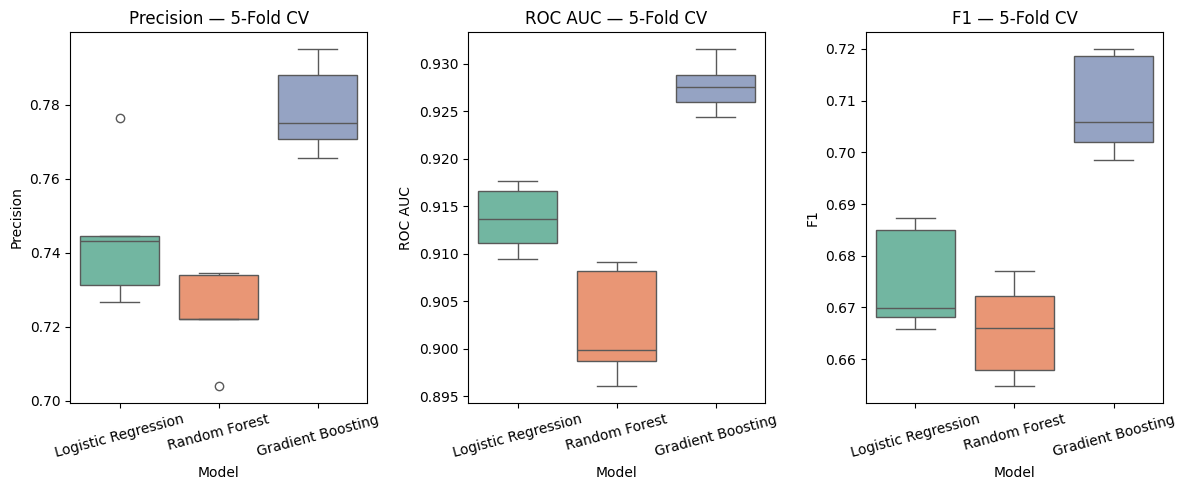

In [7]:
# 1. Define the metrics to plot: (dict_key, plot_title, y_label)
metrics = [
    ("test_precision", "Precision — 5-Fold CV", "Precision"),
    ("test_roc_auc", "ROC AUC — 5-Fold CV", "ROC AUC"),
    ("test_f1", "F1 — 5-Fold CV", "F1"),
]

# 2. Reshape all metrics into a single tidy DataFrame
data = []
for name in models:
    for metric_key, _, y_label in metrics:
        for score in cv_results[name][metric_key]:
            data.append({"Model": name, "Metric": y_label, "Score": score})

df_all = pd.DataFrame(data)

# 3. Plot in a concise loop
fig, axes = plt.subplots(1, len(metrics), figsize=(12, 5))

for ax, (_, title, y_label) in zip(axes, metrics):
    metric_data = df_all[df_all["Metric"] == y_label]
    sns.boxplot(
        data=metric_data,
        x="Model",
        y="Score",
        hue="Model",
        palette="Set2",
        legend=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

The boxplots visually support the numerical cross-validation results. Gradient Boosting consistently achieves higher Precision and ROC AUC scores across the five folds than both Logistic Regression and Random Forest. Its score distributions are generally higher with relatively small variability, suggesting stable performance across different train-validation splits. In contrast, Logistic Regression and Random Forest show greater overlap and slightly larger variation between folds, indicating less consistent performance.

## Task 4: Statistical Comparison & Feature Importance

In [8]:
# Identify top 2 models by mean precision (primary metric), then run a paired test
mean_precisions = {name: cv_results[name]["test_precision"].mean() for name in models}
ranked = sorted(mean_precisions.items(), key=lambda x: x[1], reverse=True)
top_2_names = [ranked[0][0], ranked[1][0]]
print(f"Top 2 models by mean precision: {top_2_names}")

scores_a = cv_results[top_2_names[0]]["test_precision"]
scores_b = cv_results[top_2_names[1]]["test_precision"]

# Paired t-test (5 folds is a small sample; Wilcoxon is the nonparametric alternative)
t_stat, p_value_t = stats.ttest_rel(scores_a, scores_b)
w_stat, p_value_w = stats.wilcoxon(scores_a, scores_b)

print(f"\nPaired t-test:  t={t_stat:.4f}, p={p_value_t:.4f}")
print(f"Wilcoxon test:  W={w_stat:.4f}, p={p_value_w:.4f}")

alpha = 0.05
if p_value_t < alpha:
    print(f"\np < {alpha}: the difference between {top_2_names[0]} and {top_2_names[1]} is statistically significant.")
else:
    print(f"\np >= {alpha}: no statistically significant difference detected between the top 2 models on this metric "
          f"(with only 5 folds, this test has low power — treat the result as suggestive, not conclusive).")

Top 2 models by mean precision: ['Gradient Boosting', 'Logistic Regression']

Paired t-test:  t=7.4175, p=0.0018
Wilcoxon test:  W=0.0000, p=0.0625

p < 0.05: the difference between Gradient Boosting and Logistic Regression is statistically significant.


**Practical interpretation:** The paired t-test shows a statistically significant difference (p = 0.0018), while the Wilcoxon signed-rank test falls just short of the conventional 0.05 threshold (p = 0.0625). This discrepancy is expected with only five paired observations (one per CV fold), as the Wilcoxon test has limited statistical power with such a small sample size. Notably, W = 0.0000 indicates that Gradient Boosting outperformed Logistic Regression in every fold, demonstrating a highly consistent performance advantage. Since cross-validation fold scores are not completely independent, these statistical results should be interpreted as supportive evidence rather than definitive proof.

Beyond statistical significance, the practical improvement is also meaningful. Gradient Boosting achieved a mean precision of **0.7789** compared with **0.7444** for Logistic Regression, an improvement of approximately **3.5 percentage points**. It also achieved higher ROC AUC and F1 scores while maintaining stable performance across the five folds. Together, these results support selecting Gradient Boosting as the strongest candidate for the next stage of hyperparameter tuning.

In [9]:
# Feature importance / coefficients for the engineered features specifically
# Fit each top model on the full training set once to extract importances

feature_names_out = None

for name in top_2_names:
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", models[name])])
    pipeline.fit(X_train, y_train)
    feature_names_out = pipeline.named_steps["preprocessor"].named_steps["column_transform"].get_feature_names_out()

    classifier = pipeline.named_steps["classifier"]
    if hasattr(classifier, "coef_"):
        importances = classifier.coef_[0]
        importance_label = "Coefficient"
    elif hasattr(classifier, "feature_importances_"):
        importances = classifier.feature_importances_
        importance_label = "Importance"
    else:
        print(f"{name}: no direct importance/coefficient attribute (e.g. HistGradientBoosting) — use permutation importance instead.")
        continue

    importance_df = pd.DataFrame({
        "Feature": feature_names_out,
        importance_label: importances
    })

    # Filter to just the engineered features
    engineered_cols = ["has_capital_gain", "log_capital_gain", "higher_education", "edu_hours_interaction",
                        "age_bucket", "hours_bucket"]
    engineered_mask = importance_df["Feature"].str.contains("|".join(engineered_cols))
    print(f"\n{name} — engineered feature {importance_label.lower()}s:")
    print(importance_df[engineered_mask].sort_values(importance_label, ascending=False, key=abs))

Gradient Boosting: no direct importance/coefficient attribute (e.g. HistGradientBoosting) — use permutation importance instead.

Logistic Regression — engineered feature coefficients:
                         Feature  Coefficient
7          num__log_capital_gain     6.079399
6          num__has_capital_gain    -5.710401
119  cat__hours_bucket_part-time    -1.124335
116          cat__age_bucket_65+    -1.045416
117          cat__age_bucket_<25    -0.962087
113        cat__age_bucket_35-44     0.413140
114        cat__age_bucket_45-54     0.369509
120   cat__hours_bucket_standard    -0.281619
9     num__edu_hours_interaction    -0.278653
115        cat__age_bucket_55-64    -0.171896
118  cat__hours_bucket_over-time     0.167573
112        cat__age_bucket_25-34     0.158370
8          num__higher_education     0.074668


In [10]:
from sklearn.inspection import permutation_importance

gb_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", models["Gradient Boosting"])])
gb_pipeline.fit(X_train, y_train)

perm_result = permutation_importance(
    gb_pipeline, X_test, y_test,
    n_repeats=10, random_state=42, scoring="precision", n_jobs=-1
)

# Use raw X_test column names, NOT the one-hot-encoded feature_names_out
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_result.importances_mean
}).sort_values("Importance", ascending=False)

print("Gradient Boosting — permutation importance (raw features):")
print(perm_df)

Gradient Boosting — permutation importance (raw features):
           Feature  Importance
10    capital-gain    0.139189
5   marital-status    0.095265
4    education-num    0.063615
11    capital-loss    0.026180
1        workclass    0.011274
6       occupation    0.010677
0              age    0.006095
2           fnlwgt    0.004165
13  native-country    0.000954
8             race    0.000902
3        education   -0.000078
9              sex   -0.001493
12  hours-per-week   -0.003150
7     relationship   -0.004577


**Which engineered features mattered most?** Among the 6 engineered features, log_capital_gain mattered most consistently across both models it was the strongest Logistic Regression coefficient and its parent feature (capital-gain) had the highest permutation importance in Gradient Boosting. edu_hours_interaction also contributed meaningfully, consistent with its top MI score in Task 1. In contrast, has_capital_gain added little beyond log_capital_gain (weakest MI score, unstable/redundant coefficient), and age_bucket, despite a strong standalone pattern in Task 1, showed low marginal importance in the multivariate Gradient Boosting model — likely because correlated features like marital-status already captured similar signal. This distinction between univariate signal (Task 1) and multivariate importance (Task 4) is itself a useful finding: not every individually-predictive feature remains important once combined with other, overlapping features.

Permutation importance (which reflects the combined effect of each raw feature and its derived engineered versions, since they're computed from the same underlying column) shows capital-gain (and its log/binary derivatives) as the strongest contributor (0.139), followed by marital-status (0.095) and education-num (0.064). Notably, age (+ age_bucket) contributes very little (0.006) despite showing a clear inverted-U pattern in Task 1's grouped means likely because Gradient Boosting captures overlapping signal through correlated features like marital-status and edu_hours_interaction, reducing age's marginal/independent contribution once those are present. This illustrates a key difference between univariate signal (Task 1's MI scores) and multivariate model importance (Task 4's permutation results): a feature can be individually predictive yet contribute little once stronger, correlated features are already in the model.

## Task 5: Feature Selection / Dimensionality Check

In [11]:
# SelectKBest with mutual information, measuring CV performance and training time before/after

def build_full_pipeline(classifier, use_selection=False, k=30):
    steps = [("preprocessor", preprocessor)]
    if use_selection:
        steps.append(("feature_selection", SelectKBest(score_func=mutual_info_classif, k=k)))
    steps.append(("classifier", classifier))
    return Pipeline(steps=steps)

best_model_name = ranked[0][0]
best_model = models[best_model_name]

# Baseline: no feature selection
start = time.time()
pipeline_full = build_full_pipeline(best_model, use_selection=False)
scores_full = cross_validate(pipeline_full, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
time_full = time.time() - start

# With feature selection (k=30, adjust based on total feature count after one-hot encoding)
start = time.time()
pipeline_selected = build_full_pipeline(best_model, use_selection=True, k=30)
scores_selected = cross_validate(pipeline_selected, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
time_selected = time.time() - start

print(f"{best_model_name} — full feature set:")
print(f"  Precision: {scores_full['test_precision'].mean():.4f} +/- {scores_full['test_precision'].std():.4f}")
print(f"  Training time: {time_full:.2f}s")

print(f"\n{best_model_name} — SelectKBest (k=30):")
print(f"  Precision: {scores_selected['test_precision'].mean():.4f} +/- {scores_selected['test_precision'].std():.4f}")
print(f"  Training time: {time_selected:.2f}s")

print(f"\nPrecision change: {scores_selected['test_precision'].mean() - scores_full['test_precision'].mean():+.4f}")
print(f"Time change: {time_selected - time_full:+.2f}s")

Gradient Boosting — full feature set:
  Precision: 0.7789 +/- 0.0110
  Training time: 17.96s

Gradient Boosting — SelectKBest (k=30):
  Precision: 0.7714 +/- 0.0160
  Training time: 109.85s

Precision change: -0.0075
Time change: +91.89s


SelectKBest with mutual information as the scoring function was evaluated using **k = 30**. Compared with the full feature set, precision decreased slightly (**0.7789 → 0.7714**) while total cross-validation training time increased substantially (**17.96 s → 109.85 s**). The slight reduction in precision suggests that some of the discarded features (from the approximately 121 one-hot encoded columns) contributed useful predictive information that HistGradientBoostingClassifier was able to utilize effectively. The increase in training time is primarily explained by the computational cost of calculating mutual information within each cross-validation fold, which outweighed any reduction in model training time from using fewer features.

**Decision:** Retain the complete feature set for tomorrow's hyperparameter tuning. In this experiment, SelectKBest with mutual information did not improve either predictive performance or overall computational efficiency. Although feature selection can reduce training time in some scenarios, its preprocessing cost exceeded the potential savings here. Furthermore, HistGradientBoostingClassifier is inherently robust to weak or redundant features through its tree-based learning process, so explicit feature selection provided little additional benefit. Therefore, the full engineered feature set will be used for hyperparameter tuning, while alternative feature-selection approaches (such as L1-based selection) could be explored in future work if computational efficiency becomes a priority.